# Metamodele XGBoost — MAELIA (extrapolation)

XGBoost entraine sur le meme jeu de donnees que le PCE. Adapte a l'**extrapolation** (arbres de decision, pas d'hypothese de stationnarite). CV stratifiee par simulation identique au PCE pour comparaison directe.

Indices de Sobol estimes par le **schema de Saltelli** applique au metamodele entraine.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

XML_DIR = Path('/tmp/maelia_smt_xml')
OUTPUT_COLS   = ['N_lixi', 'dCorg', 'rdt']
OUTPUT_LABELS = ['N lixivie (kgN/ha)', 'dC organique (kgC/ha)', 'Rendement (t/ha)']
OUTPUT_COLORS = ['#e74c3c', '#3498db', '#2ecc71']
SOL_TYPES  = ['18960_27491', '330104_330367_1', '330151_330489_1']
ZONE_MAP   = {'beauce': 0, 'oceanique': 1, 'sudouest': 2}
ZONE_NAMES = {0: 'beauce', 1: 'oceanique', 2: 'sudouest'}
ZONE_COLORS = {0: '#3498db', 1: '#e67e22', 2: '#2ecc71'}
N_FOLDS_CV = 5
RANDOM_SEED = 42

INPUT_LABELS = [
    'Nb apports fertilisation', 'Preparation sol (oui/non)', 'Nb operations prepa sol',
    'Type prepa sol 1', 'Type prepa sol 2', 'Nb produits engrais F1',
    'Type engrais F1-1', 'Type engrais F1-2', 'Nb produits engrais F2',
    'Type engrais F2-1', 'Type engrais F2-2', 'Nb produits engrais F3',
    'Type engrais F3-1', 'Type engrais F3-2', 'Jour de semis (j/an)',
    'Jours avant prepa sol', 'Jours semis -> F1', 'Jours F1 -> F2',
    'Jours F2 -> F3', 'Jours op. -> recolte', 'Dose F1-1 (kgN/ha)',
    'Dose F1-2 (kgN/ha)', 'Dose F2-1 (kgN/ha)', 'Dose F2-2 (kgN/ha)',
    'Dose F3-1 (kgN/ha)', 'Dose F3-2 (kgN/ha)',
    'Zone beauce (indicatrice)', 'Zone oceanique (indicatrice)',
    'Sol A - 18960_27491', 'Sol B - 330104_330367_1',
]
N_INPUTS = len(INPUT_LABELS)
VAR_BOUNDS = [
    (0,3),(0,1),(0,1),(0,3),(0,3),(0,1),(0,3),(0,3),(0,1),(0,3),(0,3),
    (0,1),(0,3),(0,3),(260,320),(1,30),(100,250),(1,60),(1,60),(1,250),
    (10,100),(10,100),(10,100),(10,100),(10,100),(10,100),
    (0,1),(0,1),(0,1),(0,1),
]
print(f'XGBoost {xgb.__version__}  |  {N_INPUTS} inputs  |  {N_FOLDS_CV}-fold CV stratifiee')

XGBoost 3.1.2  |  30 inputs  |  5-fold CV stratifiee


## 1. Chargement & construction de X, Y

In [2]:
xt          = np.load(XML_DIR / 'doe_xt.npy')
is_acting_t = np.load(XML_DIR / 'doe_is_acting.npy')
df_mm       = pd.read_csv(XML_DIR / 'dataset_metamodel.csv')
N_DOE       = xt.shape[0]

rows_X, rows_Y, row_sim_idx, row_zone_id = [], [], [], []
for _, row in df_mm.iterrows():
    idx  = int(row['sim_idx'])
    zone = row['zone']
    if zone not in ZONE_MAP:
        continue
    sol   = row.get('sol_type', None)
    x_smt = xt[idx].astype(float).copy()
    x_smt[~is_acting_t[idx]] = np.nan
    zo    = ZONE_MAP[zone]
    rows_X.append(np.concatenate([
        x_smt,
        [1. if zo==0 else 0., 1. if zo==1 else 0.,
         1. if sol==SOL_TYPES[0] else 0., 1. if sol==SOL_TYPES[1] else 0.]
    ]))
    rows_Y.append([row.get(c, np.nan) for c in OUTPUT_COLS])
    row_sim_idx.append(idx)
    row_zone_id.append(zo)

X_raw   = np.array(rows_X)
Y_raw   = np.array(rows_Y)
SIM_IDX = np.array(row_sim_idx)
ZONE_IDS = np.array(row_zone_id)

# Imputation par la moyenne
X_imp    = X_raw.copy()
imp_means = np.nanmean(X_imp, axis=0)
for j in range(N_INPUTS):
    mask = np.isnan(X_imp[:, j])
    X_imp[mask, j] = imp_means[j]

print(f'X : {X_imp.shape}  Y : {Y_raw.shape}  ({N_DOE} simulations x {len(df_mm)//N_DOE} parcelles)')

X : (13000, 30)  Y : (13000, 3)  (100 simulations x 130 parcelles)


## 2. Entrainement XGBoost + CV stratifiee

In [8]:
XGB_PARAMS = dict(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, random_state=RANDOM_SEED,
    n_jobs=-1, tree_method='hist',
)

kf = KFold(n_splits=N_FOLDS_CV, shuffle=True, random_state=RANDOM_SEED)

def stratified_cv_q2(X, y, sim_arr):
    unique_sims = np.unique(sim_arr)
    yt_all, yp_all, zone_all = [], [], []
    for tr_idx, te_idx in kf.split(unique_sims):
        tr_sims = set(unique_sims[tr_idx])
        te_sims = set(unique_sims[te_idx])
        tr = np.array([i for i, s in enumerate(sim_arr) if s in tr_sims])
        te = np.array([i for i, s in enumerate(sim_arr) if s in te_sims])
        m  = xgb.XGBRegressor(**XGB_PARAMS)
        m.fit(X[tr], y[tr])
        yt_all.extend(y[te])
        yp_all.extend(m.predict(X[te]))
        zone_all.extend(ZONE_IDS[valid_masks[col]][te])
    return r2_score(yt_all, yp_all), np.array(yt_all), np.array(yp_all), np.array(zone_all)

models      = {}
metrics     = {}
valid_masks = {}
oof_preds   = {}  # predictions out-of-fold par sortie

for col in OUTPUT_COLS:
    k    = OUTPUT_COLS.index(col)
    y    = Y_raw[:, k]
    mask = ~np.isnan(y)
    valid_masks[col] = mask
    m    = xgb.XGBRegressor(**XGB_PARAMS)
    m.fit(X_imp[mask], y[mask])
    models[col] = m
    r2_tr = r2_score(y[mask], m.predict(X_imp[mask]))
    q2, yt, yp, zo = stratified_cv_q2(X_imp[mask], y[mask], SIM_IDX[mask])
    metrics[col]   = dict(R2_train=r2_tr, Q2_strat=q2, n=int(mask.sum()))
    oof_preds[col] = dict(y_true=yt, y_pred=yp, zone=zo)
    qlt = 'Bon' if q2 > 0.7 else 'Acceptable' if q2 > 0.4 else 'Faible'
    print(f'{col:<8}  R2={r2_tr:.3f}  Q2_strat={q2:.3f}  -> {qlt}')


N_lixi    R2=0.931  Q2_strat=0.746  -> Bon
dCorg     R2=0.972  Q2_strat=-0.123  -> Faible
rdt       R2=0.666  Q2_strat=-0.219  -> Faible


## 3. Graphique de validation (predit vs observe)

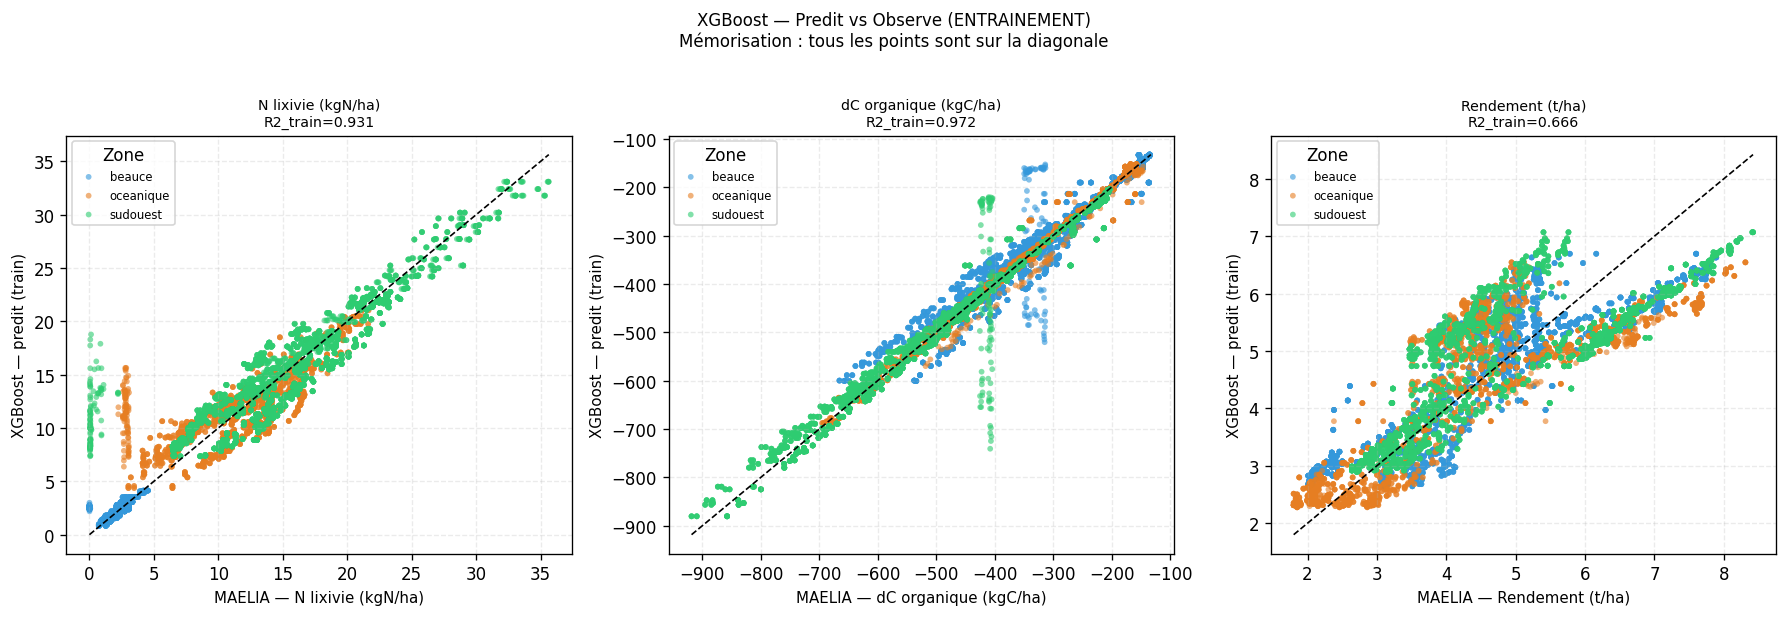

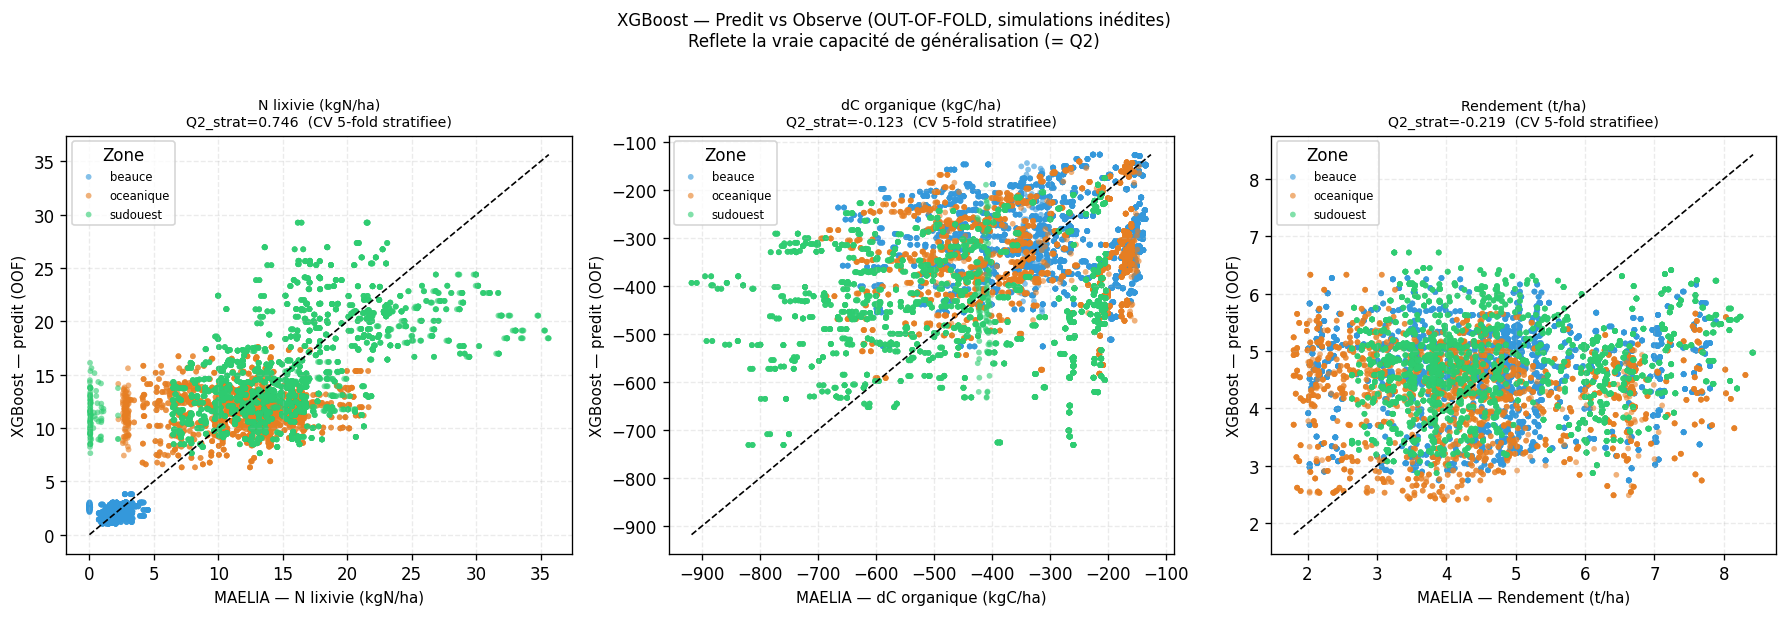

In [9]:
def scatter_by_zone(axes, y_true_list, y_pred_list, zone_list, title_fn, ylabel):
    for ax, col, lbl, color in zip(axes, OUTPUT_COLS, OUTPUT_LABELS, OUTPUT_COLORS):
        y_tr, y_pr, z_ids = y_true_list[col], y_pred_list[col], zone_list[col]
        m = metrics[col]
        for z_id in [0, 1, 2]:
            zm = (z_ids == z_id)
            ax.scatter(y_tr[zm], y_pr[zm], c=ZONE_COLORS[z_id], s=12,
                       alpha=0.6, edgecolors='none', label=ZONE_NAMES[z_id])
        lims = [min(y_tr.min(), y_pr.min()), max(y_tr.max(), y_pr.max())]
        ax.plot(lims, lims, 'k--', lw=1)
        ax.set_xlabel(f'MAELIA — {lbl}', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title_fn(col, lbl, m), fontsize=8.5)
        ax.legend(fontsize=7, title='Zone', loc='upper left')
        ax.grid(alpha=0.25, linestyle='--')

# ── Figure 1 : entrainement (R2) ─────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
scatter_by_zone(
    axes1,
    {c: Y_raw[valid_masks[c], OUTPUT_COLS.index(c)] for c in OUTPUT_COLS},
    {c: models[c].predict(X_imp[valid_masks[c]])    for c in OUTPUT_COLS},
    {c: ZONE_IDS[valid_masks[c]]                    for c in OUTPUT_COLS},
    lambda col, lbl, m: f'{lbl}\nR2_train={m["R2_train"]:.3f}',
    ylabel='XGBoost — predit (train)',
)
fig1.suptitle('XGBoost — Predit vs Observe (ENTRAINEMENT)\nMémorisation : tous les points sont sur la diagonale',
              fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(XML_DIR / 'xgboost_validation_train.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2 : out-of-fold (Q2) ──────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
scatter_by_zone(
    axes2,
    {c: oof_preds[c]['y_true'] for c in OUTPUT_COLS},
    {c: oof_preds[c]['y_pred'] for c in OUTPUT_COLS},
    {c: oof_preds[c]['zone']   for c in OUTPUT_COLS},
    lambda col, lbl, m: f'{lbl}\nQ2_strat={m["Q2_strat"]:.3f}  (CV 5-fold stratifiee)',
    ylabel='XGBoost — predit (OOF)',
)
fig2.suptitle('XGBoost — Predit vs Observe (OUT-OF-FOLD, simulations inédites)\nReflete la vraie capacité de généralisation (= Q2)',
              fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(XML_DIR / 'xgboost_validation_oof.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Indices de Sobol (schema de Saltelli)

In [5]:
def compute_sobol_s1(predict_fn, bounds, N=2048, seed=42):
    """Estimateur de Saltelli/Jansen pour S1."""
    rng = np.random.default_rng(seed)
    d   = len(bounds)
    lo  = np.array([b[0] for b in bounds])
    hi  = np.array([b[1] for b in bounds])
    A   = lo + rng.random((N, d)) * (hi - lo)
    B   = lo + rng.random((N, d)) * (hi - lo)
    fA  = predict_fn(A)
    fB  = predict_fn(B)
    var_Y = np.var(np.concatenate([fA, fB]))
    S1 = np.zeros(d)
    for i in range(d):
        AB_i = A.copy(); AB_i[:, i] = B[:, i]
        fABi = predict_fn(AB_i)
        S1[i] = max(0., 1. - 0.5 * np.mean((fB - fABi)**2) / (var_Y + 1e-12))
    return S1

sobol_S1 = {}
for col in OUTPUT_COLS:
    fn = lambda X, m=models[col]: m.predict(X)
    sobol_S1[col] = compute_sobol_s1(fn, VAR_BOUNDS, N=2048)
    print(f'{col}  Somme S1 = {sobol_S1[col].sum():.3f}')

N_lixi  Somme S1 = 0.923
dCorg  Somme S1 = 0.866
rdt  Somme S1 = 0.968


## 5. Visualisation des indices de Sobol

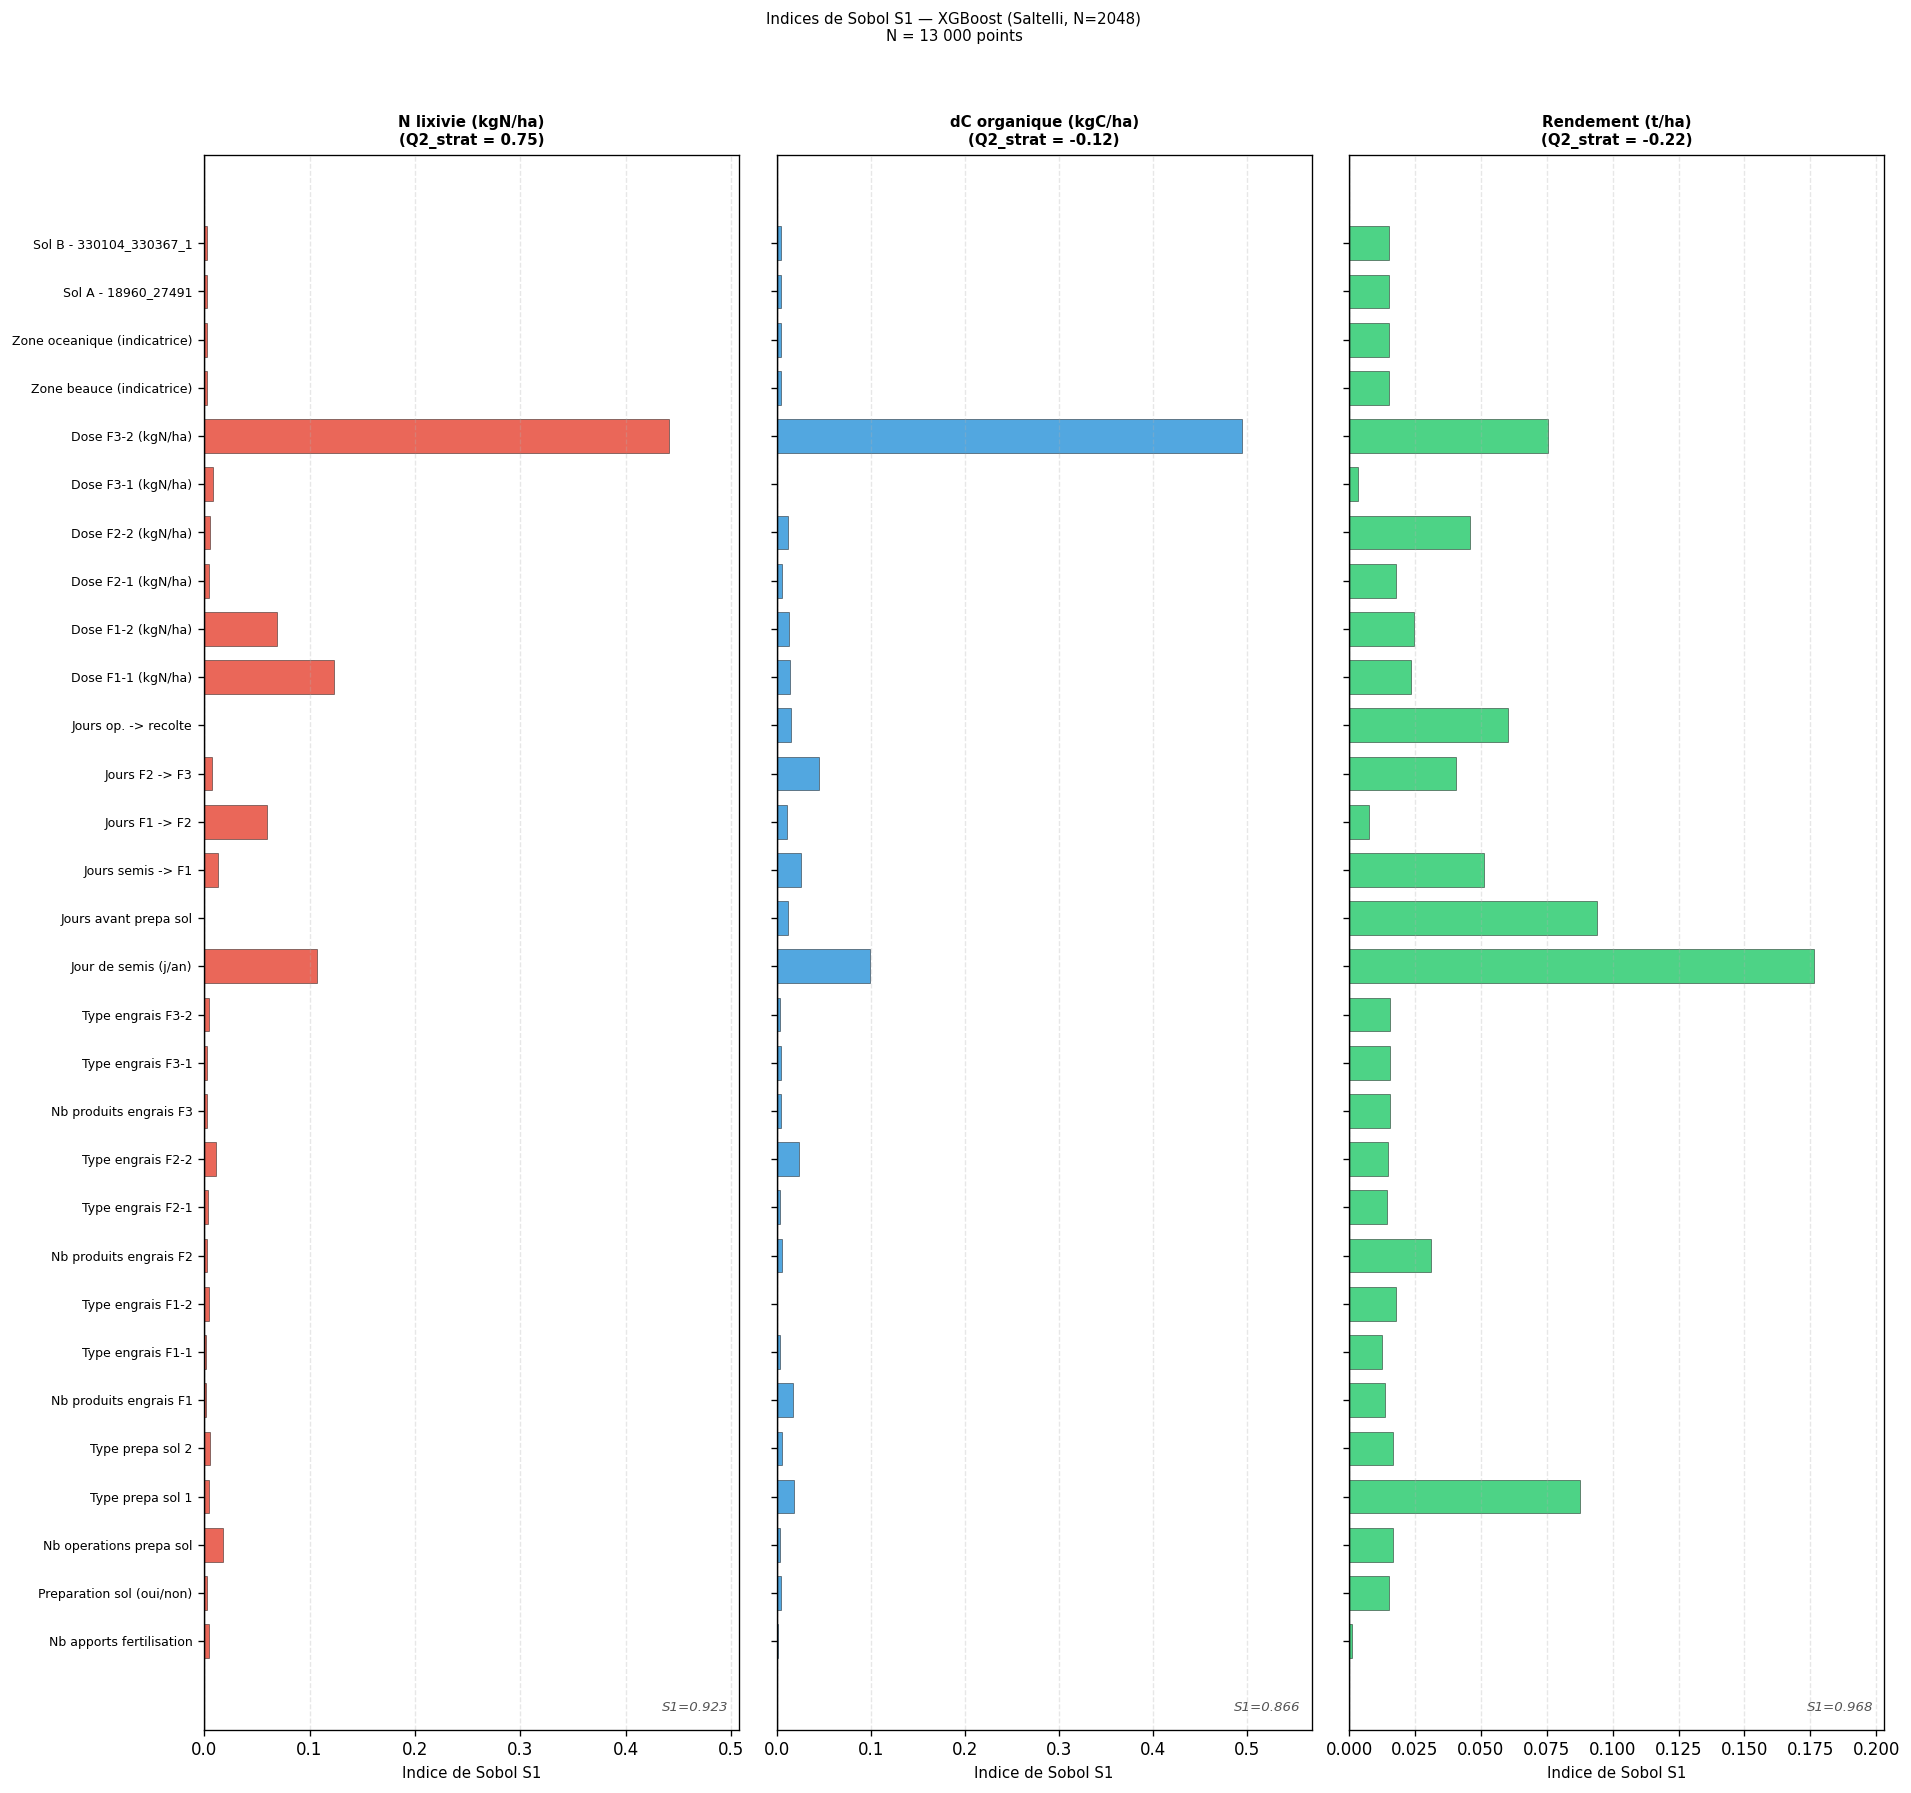

Figures -> /tmp/maelia_smt_xml/xgboost_validation.png  et  xgboost_sobol.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, max(8, 0.42 * N_INPUTS + 2)), sharey=True)
y_pos = np.arange(N_INPUTS)

for ax, col, lbl, color in zip(axes, OUTPUT_COLS, OUTPUT_LABELS, OUTPUT_COLORS):
    s1 = sobol_S1[col]
    m  = metrics[col]
    ax.barh(y_pos, s1, color=color, alpha=0.85, edgecolor='k', linewidth=0.3, height=0.7)
    ax.set_xlim(0, max(s1.max() * 1.15, 0.05))
    ax.set_xlabel('Indice de Sobol S1', fontsize=9)
    ax.set_title(f'{lbl}\n(Q2_strat = {m["Q2_strat"]:.2f})', fontsize=9, fontweight='bold')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(INPUT_LABELS, fontsize=7.5)
    ax.axvline(0, color='k', lw=0.8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.text(0.98, 0.01, f'S1={s1.sum():.3f}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='#555', style='italic')

fig.suptitle('Indices de Sobol S1 — XGBoost (Saltelli, N=2048)\nN = 13 000 points',
             fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig(XML_DIR / 'xgboost_sobol.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figures -> {XML_DIR}/xgboost_validation.png  et  xgboost_sobol.png')